# Notebook 10 — Predicción Supervisada de Reorder

En los notebooks anteriores construimos recomendadores **no supervisados**: popularidad (NB06), reglas de asociación (NB07/NB08) y filtrado colaborativo item-item (NB09). Ninguno de ellos "aprende" a partir de una etiqueta conocida: arman recomendaciones a partir de patrones de co-ocurrencia o similitud, sin un objetivo explícito de acierto/error.

Acá construimos algo distinto: un **modelo supervisado de clasificación binaria**. Le vamos a dar ejemplos históricos de la forma *"el usuario U ya compró el producto P antes; ¿lo volvió a comprar en su próximo pedido?"* (respuesta sí/no conocida), y el modelo va a aprender a predecir esa respuesta para pares nuevos.

**Pregunta de negocio:** dado un usuario y uno o varios productos que ya compró alguna vez, ¿cuáles de esos productos va a volver a pedir en su próximo pedido? Esto habilita casos de uso concretos: sugerir "comprá de nuevo" al armar el carrito, priorizar qué mostrarle primero, o alimentar campañas de recompra personalizadas.

**Formato de entrada/salida del modelo ganador:**
- **Entrada:** `user_id` + una lista de `product_id` (productos que ya compró alguna vez).
- **Salida:** por cada producto, un `"si"`/`"no"` (más la probabilidad detrás de esa decisión).

**Modelos que vamos a comparar:** RandomForest (como *baseline* simple e interpretable), y tres modelos de *gradient boosting* que suelen dar mejores resultados en datos tabulares: XGBoost, LightGBM y CatBoost. Vamos a entrenar los cuatro con las mismas features y compararlos con las mismas métricas, explicando qué mide cada una y por qué importa para este problema de negocio.

Este notebook es autónomo: lee los CSV crudos de Instacart y no depende de artefactos generados por otros notebooks.

## Fase 0 — Setup e imports

Importamos las librerías de datos (`pandas`, `numpy`), los 4 algoritmos de clasificación a comparar, las funciones de métricas de `scikit-learn`, y definimos las rutas y constantes del notebook (semilla fija para que todo sea reproducible).

In [2]:
import sys
import json
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    log_loss,
    precision_recall_curve,
    roc_curve,
    confusion_matrix,
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# --- Rutas ------------------------------------------------------------------
DATA_RAW  = Path('../data/raw/instacart')
DATA_PROC = Path('../data/processed')
MODELS    = Path('../models')

_project_root = str(Path('..').resolve())
if _project_root not in sys.path:
    sys.path.insert(0, _project_root)

# --- Reproducibilidad y parámetros ------------------------------------------
RANDOM_STATE   = 42
N_USERS_SAMPLE = 100_000  # cantidad de usuarios a muestrear para este notebook
TEST_SIZE      = 0.2      # proporcion de usuarios para validacion

print('Setup completo.')
print(f'  DATA_RAW  : {DATA_RAW.resolve()}')
print(f'  DATA_PROC : {DATA_PROC.resolve()}')
print(f'  MODELS    : {MODELS.resolve()}')

Setup completo.
  DATA_RAW  : C:\henry\ProyectoFinal-DataScience-Henry\data\raw\instacart
  DATA_PROC : C:\henry\ProyectoFinal-DataScience-Henry\data\processed
  MODELS    : C:\henry\ProyectoFinal-DataScience-Henry\models


## Fase 1 — Carga de datos y construcción del dataset supervisado

### ¿Cómo está organizado el dataset de Instacart?

La tabla `orders.csv` clasifica cada pedido con la columna `eval_set` en tres grupos:

- **`prior`**: el historial completo de pedidos pasados de cada usuario. Es de donde vamos a sacar los **candidatos** (productos que el usuario ya compró alguna vez) y las **features** (su comportamiento pasado).
- **`train`**: para un subconjunto de usuarios, este es *el próximo pedido después de su historial prior* — y sabemos exactamente qué compraron en él. Es la fuente de la **etiqueta** (`y`) que queremos predecir.
- **`test`**: igual que `train` pero sin revelar qué se compró (es el holdout que usaba la competencia de Kaggle). No lo usamos porque no tiene etiqueta.

Cargamos `orders.csv` primero, con tipos de datos livianos (`int32`, `int8`, etc.) para no consumir memoria de más — el dataset completo tiene más de 3 millones de pedidos.

In [3]:
orders = pd.read_csv(
    DATA_RAW / 'orders.csv',
    dtype={
        'order_id': 'int32',
        'user_id': 'int32',
        'eval_set': 'category',
        'order_number': 'int16',
        'order_dow': 'int8',
        'order_hour_of_day': 'int8',
        'days_since_prior_order': 'float32',
    },
)
orders.head()

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,7,29.0
4,431534,1,prior,5,4,15,28.0


In [4]:
# Cuantos pedidos hay de cada tipo
orders['eval_set'].value_counts()

eval_set
prior    3214874
train     131209
test       75000
Name: count, dtype: int64

### Muestreo de usuarios

El dataset completo tiene ~206.000 usuarios y más de 32 millones de filas en `order_products__prior.csv`. Entrenar 4 modelos distintos sobre todo eso es lento y pesado en memoria para un notebook de desarrollo. Por eso trabajamos con una **muestra reproducible de 100.000 usuarios** (semilla fija `RANDOM_STATE`), tomada solo de los usuarios que tienen pedido `train` (los únicos para los que existe una etiqueta conocida).

Muestreamos **usuarios completos**, no filas sueltas: así conservamos intacto el historial de cada usuario muestreado, que es justamente lo que necesitamos para construir las features.

In [5]:
train_users_all = orders.loc[orders['eval_set'] == 'train', 'user_id'].unique()
print(f'Usuarios con pedido objetivo (train): {len(train_users_all):,}')

rng = np.random.default_rng(RANDOM_STATE)
n_sample = min(N_USERS_SAMPLE, len(train_users_all))
sample_users = np.sort(rng.choice(train_users_all, size=n_sample, replace=False))
print(f'Usuarios muestreados para este notebook: {len(sample_users):,}')

Usuarios con pedido objetivo (train): 131,209
Usuarios muestreados para este notebook: 100,000


In [6]:
# Nos quedamos solo con los pedidos (prior y train) de los usuarios muestreados
orders_sample = orders[orders['user_id'].isin(sample_users)].copy()

orders_prior_meta = orders_sample[orders_sample['eval_set'] == 'prior'].copy()
orders_train_meta = orders_sample[orders_sample['eval_set'] == 'train'].copy()

prior_order_ids = set(orders_prior_meta['order_id'])
train_order_ids = set(orders_train_meta['order_id'])

print(f'Pedidos prior de la muestra: {len(prior_order_ids):,}')
print(f'Pedidos train (el "proximo pedido") de la muestra: {len(train_order_ids):,}')

Pedidos prior de la muestra: 1,562,457
Pedidos train (el "proximo pedido") de la muestra: 100,000


### Carga de los productos comprados en cada pedido

`order_products__prior.csv` tiene 32M+ filas (una fila por producto comprado en cada pedido `prior`, de todos los usuarios). Como ya sabemos qué `order_id` nos interesan (los de nuestra muestra), lo leemos **por bloques** (`chunksize`) y nos quedamos solo con esas filas en cada bloque — así evitamos cargar el archivo completo en memoria de una sola vez.

In [7]:
chunks = []
for chunk in pd.read_csv(
    DATA_RAW / 'order_products__prior.csv',
    dtype={
        'order_id': 'int32',
        'product_id': 'int32',
        'add_to_cart_order': 'int16',
        'reordered': 'int8',
    },
    chunksize=2_000_000,
):
    chunks.append(chunk[chunk['order_id'].isin(prior_order_ids)])

order_products_prior = pd.concat(chunks, ignore_index=True)
del chunks

print(f'Filas de order_products__prior (solo muestra): {len(order_products_prior):,}')

Filas de order_products__prior (solo muestra): 15,745,948


`order_products__train.csv` es mucho más chico (solo tiene los productos del "próximo pedido" de los usuarios `train`), así que lo cargamos entero y filtramos después.

In [8]:
order_products_train = pd.read_csv(
    DATA_RAW / 'order_products__train.csv',
    dtype={
        'order_id': 'int32',
        'product_id': 'int32',
        'add_to_cart_order': 'int16',
        'reordered': 'int8',
    },
)
order_products_train = order_products_train[order_products_train['order_id'].isin(train_order_ids)]
print(f'Filas de order_products__train (solo muestra): {len(order_products_train):,}')

Filas de order_products__train (solo muestra): 1,055,711


### Tabla base: compras `prior` con usuario y número de pedido

Unimos `order_products_prior` con los metadatos de pedido (`user_id`, `order_number`, `days_since_prior_order`) para tener, en una sola tabla, todo lo necesario para construir candidatos y features. Esta tabla (`op_prior_user`) es la base de todo lo que sigue.

In [9]:
op_prior_user = order_products_prior.merge(
    orders_prior_meta[['order_id', 'user_id', 'order_number', 'days_since_prior_order']],
    on='order_id',
    how='left',
)
op_prior_user.head()

,order_id,product_id,add_to_cart_order,reordered,user_id,order_number,days_since_prior_order
0,2,33120,1,1,202279,3,8.0
1,2,28985,2,1,202279,3,8.0
2,2,9327,3,0,202279,3,8.0
3,2,45918,4,1,202279,3,8.0
4,2,30035,5,0,202279,3,8.0


### Construcción de los candidatos (usuario, producto)

Un **candidato** es cualquier par (usuario, producto) donde el usuario compró ese producto **al menos una vez** en su historial `prior`. Esta es la población completa sobre la que el modelo va a tener que decidir sí/no — tiene sentido: no tendría lógica preguntarle al modelo por un producto que el usuario nunca compró (eso ya lo cubren los otros recomendadores, como MBA o CF).

In [10]:
candidates = (
    op_prior_user[['user_id', 'product_id']]
    .drop_duplicates()
    .reset_index(drop=True)
)
print(f'Pares candidatos (usuario, producto): {len(candidates):,}')
candidates.head()

Pares candidatos (usuario, producto): 6,462,910


,user_id,product_id
0,202279,33120
1,202279,28985
2,202279,9327
3,202279,45918
4,202279,30035


### Etiqueta: ¿el producto está en el próximo pedido?

Cruzamos `order_products_train` con los usuarios para saber, por cada (usuario, producto) que aparece en el pedido `train`, que ese producto **sí** fue recomprado. Le asignamos `y=1` a esos candidatos y `y=0` al resto (compró el producto antes, pero no en el próximo pedido).

In [11]:
op_train_user = order_products_train.merge(
    orders_train_meta[['order_id', 'user_id']],
    on='order_id',
    how='left',
)

positive_pairs = (
    op_train_user[['user_id', 'product_id']]
    .drop_duplicates()
    .assign(y=1)
)

candidates = candidates.merge(positive_pairs, on=['user_id', 'product_id'], how='left')
candidates['y'] = candidates['y'].fillna(0).astype('int8')

candidates.head()

,user_id,product_id,y
0,202279,33120,1
1,202279,28985,0
2,202279,9327,0
3,202279,45918,0
4,202279,30035,0


### Balance de clases

Miremos qué tan desbalanceado está el problema: de todos los productos que un usuario compró alguna vez, ¿qué porcentaje vuelve a pedir en su próximo pedido? Es un dato clave: si el desbalance es grande, un modelo "tonto" que siempre responde "no" va a tener una **accuracy** muy alta sin ser útil para nada — por eso más adelante vamos a usar métricas que sí distinguen esto (PR-AUC, F1, etc.) en vez de solo accuracy.

Cantidad de pares por clase:
y
0    5831887
1     631023
Name: count, dtype: int64

Porcentaje por clase:
y
0    90.24
1     9.76
Name: proportion, dtype: float64


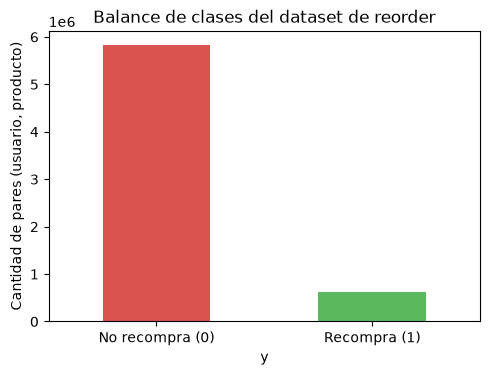

In [12]:
class_counts = candidates['y'].value_counts().sort_index()
class_pct = (candidates['y'].value_counts(normalize=True) * 100).sort_index()

print('Cantidad de pares por clase:')
print(class_counts)
print()
print('Porcentaje por clase:')
print(class_pct.round(2))

fig, ax = plt.subplots(figsize=(5, 4))
class_counts.plot(kind='bar', color=['#d9534f', '#5cb85c'], ax=ax)
ax.set_xticklabels(['No recompra (0)', 'Recompra (1)'], rotation=0)
ax.set_ylabel('Cantidad de pares (usuario, producto)')
ax.set_title('Balance de clases del dataset de reorder')
plt.tight_layout()
plt.show()

## Fase 2 — Feature Engineering

Ahora construimos las variables (*features*) que el modelo va a usar para predecir. Las agrupamos en 4 bloques, de más generales a más específicas:

1. **Features de usuario**: ¿qué tan seguido compra? ¿qué tan grande es su carrito? ¿qué tan "fiel" es a sus productos (recompra mucho o prueba cosas nuevas)?
2. **Features de producto**: ¿qué tan popular es? ¿qué tan seguido se recompra en general (hay productos "de uso diario" vs. productos "de una sola vez")?
3. **Features de usuario×producto**: la relación específica entre ESE usuario y ESE producto — son las más predictivas, porque capturan el hábito puntual (cuántas veces lo compró, hace cuánto que no lo compra, etc.).
4. **Features de contexto del próximo pedido**: el día de la semana y la hora en que se hizo el pedido objetivo, y cuántos días pasaron desde el pedido anterior. Esto es información legítima de usar porque, en un escenario real, sabemos cuándo el usuario está armando su próximo pedido.

### 2.1 — Features de usuario

- `user_n_orders`: cantidad total de pedidos `prior` del usuario (cuán activo es).
- `user_avg_basket_size`: tamaño promedio de sus pedidos (cuántos productos compra en promedio).
- `user_reorder_rate`: de todo lo que compró históricamente, qué porcentaje eran recompras (usuarios "de hábitos fijos" vs. usuarios "exploradores").
- `user_avg_days_since_prior`: cada cuántos días pedía, en promedio (frecuencia de compra).

In [13]:
user_n_orders = (
    orders_prior_meta.groupby('user_id')['order_id']
    .nunique()
    .rename('user_n_orders')
)

user_max_order_number = (
    orders_prior_meta.groupby('user_id')['order_number']
    .max()
    .rename('user_max_order_number')
)

user_avg_days_since_prior = (
    orders_prior_meta.groupby('user_id')['days_since_prior_order']
    .mean()
    .rename('user_avg_days_since_prior')
)

basket_sizes = op_prior_user.groupby(['user_id', 'order_id']).size()
user_avg_basket_size = (
    basket_sizes.groupby('user_id')
    .mean()
    .rename('user_avg_basket_size')
)

user_reorder_rate = (
    op_prior_user.groupby('user_id')['reordered']
    .mean()
    .rename('user_reorder_rate')
)

user_features = (
    pd.concat(
        [user_n_orders, user_avg_basket_size, user_reorder_rate, user_avg_days_since_prior],
        axis=1,
    )
    .reset_index()
)
user_features.head()

,user_id,user_n_orders,user_avg_basket_size,user_reorder_rate,user_avg_days_since_prior
0,1,10,5.900000,0.694915,19.555555
1,2,14,13.928571,0.476923,15.230769
2,7,20,10.300000,0.669903,10.684211
3,8,3,16.333333,0.265306,30.000000
4,9,3,25.333333,0.236842,18.000000


### 2.2 — Features de producto

- `product_n_purchases`: cuántas veces se compró el producto en toda la muestra (popularidad).
- `product_n_users`: a cuántos usuarios distintos les gusta (alcance).
- `product_reorder_rate`: qué porcentaje de sus compras son recompras — productos como "leche" o "banana" van a tener un `reorder_rate` alto; productos de compra única (por ejemplo, un regalo puntual) van a tener uno bajo.
- `product_avg_add_to_cart_order`: en qué posición promedio del carrito se agrega (los productos "obvios" suelen agregarse primero).

In [14]:
product_features = (
    op_prior_user.groupby('product_id')
    .agg(
        product_n_purchases=('order_id', 'count'),
        product_n_users=('user_id', 'nunique'),
        product_reorder_rate=('reordered', 'mean'),
        product_avg_add_to_cart_order=('add_to_cart_order', 'mean'),
    )
    .reset_index()
)
product_features.head()

,product_id,product_n_purchases,product_n_users,product_reorder_rate,product_avg_add_to_cart_order
0,1,969,343,0.646027,5.633643
1,2,37,33,0.108108,12.594595
2,3,145,36,0.751724,6.248276
3,4,153,77,0.496732,9.660131
4,5,10,3,0.700000,5.300000


### 2.3 — Features de usuario×producto

Estas son, en general, las variables más predictivas del modelo porque describen el hábito puntual de ESE usuario con ESE producto:

- `up_times_bought`: cuántas veces el usuario compró ese producto.
- `up_times_reordered`: cuántas de esas veces fueron recompras.
- `up_order_rate`: en qué porcentaje de TODOS sus pedidos aparece el producto (si compra siempre lo mismo, va a estar cerca de 1).
- `up_orders_since_last`: hace cuántos pedidos que no lo compra (recencia — 0 significa que lo compró en su último pedido).
- `up_avg_add_to_cart_order`: en qué posición promedio del carrito lo agrega ESE usuario.

In [15]:
up_agg = (
    op_prior_user.groupby(['user_id', 'product_id'])
    .agg(
        up_times_bought=('order_id', 'count'),
        up_times_reordered=('reordered', 'sum'),
        up_last_order_number=('order_number', 'max'),
        up_avg_add_to_cart_order=('add_to_cart_order', 'mean'),
    )
    .reset_index()
)

up_agg = up_agg.merge(user_n_orders.reset_index(), on='user_id', how='left')
up_agg = up_agg.merge(user_max_order_number.reset_index(), on='user_id', how='left')

up_agg['up_order_rate'] = (up_agg['up_times_bought'] / up_agg['user_n_orders']).clip(upper=1.0)
up_agg['up_orders_since_last'] = up_agg['user_max_order_number'] - up_agg['up_last_order_number']

up_features = up_agg[[
    'user_id', 'product_id',
    'up_times_bought', 'up_times_reordered',
    'up_order_rate', 'up_orders_since_last', 'up_avg_add_to_cart_order',
]]
up_features.head()

,user_id,product_id,up_times_bought,up_times_reordered,up_order_rate,up_orders_since_last,up_avg_add_to_cart_order
0,1,196,10,9,1.0,0,1.400000
1,1,10258,9,8,0.9,0,3.333333
2,1,10326,1,0,0.1,5,5.000000
3,1,12427,10,9,1.0,0,3.300000
4,1,13032,3,2,0.3,0,6.333333


### 2.4 — Features de contexto del pedido objetivo

Del pedido `train` (el "próximo pedido" que queremos predecir) sabemos cuándo se hizo, aunque no sepamos qué contiene. Esa información de contexto es útil: por ejemplo, hay productos que se compran más los fines de semana, o el tiempo desde el último pedido puede indicar si "tocaba" reabastecer algo.

In [16]:
target_context = orders_train_meta[[
    'user_id', 'order_dow', 'order_hour_of_day', 'days_since_prior_order',
]].rename(columns={
    'order_dow': 'target_order_dow',
    'order_hour_of_day': 'target_order_hour_of_day',
    'days_since_prior_order': 'target_days_since_prior_order',
})
target_context.head()

,user_id,target_order_dow,target_order_hour_of_day,target_days_since_prior_order
10,1,4,8,14.0
25,2,1,11,30.0
74,7,2,11,6.0
78,8,1,14,10.0
82,9,6,10,30.0


### 2.5 — Ensamblado del dataset final de modelado

Unimos los candidatos con los 4 bloques de features. Como los candidatos surgen exactamente de `op_prior_user`, todas las combinaciones deberían tener features completas — igual aplicamos `fillna(0)` como red de seguridad.

In [17]:
dataset = candidates.merge(user_features, on='user_id', how='left')
dataset = dataset.merge(product_features, on='product_id', how='left')
dataset = dataset.merge(up_features, on=['user_id', 'product_id'], how='left')
dataset = dataset.merge(target_context, on='user_id', how='left')

feature_cols = [
    'user_n_orders', 'user_avg_basket_size', 'user_reorder_rate', 'user_avg_days_since_prior',
    'product_n_purchases', 'product_n_users', 'product_reorder_rate', 'product_avg_add_to_cart_order',
    'up_times_bought', 'up_times_reordered', 'up_order_rate', 'up_orders_since_last', 'up_avg_add_to_cart_order',
    'target_order_dow', 'target_order_hour_of_day', 'target_days_since_prior_order',
]

n_nulos = dataset[feature_cols].isna().sum().sum()
print(f'Valores nulos antes de rellenar: {n_nulos}')
dataset[feature_cols] = dataset[feature_cols].fillna(0)

print(f'Dataset final: {dataset.shape[0]:,} filas x {dataset.shape[1]} columnas')
dataset.head()

Valores nulos antes de rellenar: 0
Dataset final: 6,462,910 filas x 19 columnas


,user_id,product_id,y,user_n_orders,user_avg_basket_size,user_reorder_rate,user_avg_days_since_prior,product_n_purchases,product_n_users,product_reorder_rate,product_avg_add_to_cart_order,up_times_bought,up_times_reordered,up_order_rate,up_orders_since_last,up_avg_add_to_cart_order,target_order_dow,target_order_hour_of_day,target_days_since_prior_order
0,202279,33120,1,8,11.25,0.477778,21.571428,9694,2759,0.715391,6.774809,5,4,0.625,0,2.000000,1,14,30.0
1,202279,28985,0,8,11.25,0.477778,21.571428,33104,10089,0.695233,7.478734,5,4,0.625,2,3.200000,1,14,30.0
2,202279,9327,0,8,11.25,0.477778,21.571428,3024,2522,0.166005,9.826720,1,0,0.125,5,3.000000,1,14,30.0
3,202279,45918,0,8,11.25,0.477778,21.571428,338,244,0.278107,8.766272,5,4,0.625,1,4.800000,1,14,30.0
4,202279,30035,0,8,11.25,0.477778,21.571428,302,140,0.536424,9.043046,3,2,0.375,1,4.666667,1,14,30.0


## Fase 3 — Split de entrenamiento / validación (sin fuga de datos)

**Importante:** no podemos partir el dataset con un split aleatorio fila por fila. Si un mismo usuario tiene filas tanto en train como en validación, el modelo estaría "viendo" parte del comportamiento de ese usuario durante el entrenamiento y luego evaluándose sobre el resto de sus propias filas — eso es **fuga de datos (data leakage)** y da métricas artificialmente buenas que no se van a replicar con usuarios nuevos.

Por eso partimos por **usuario completo**: el 80% de los usuarios va entero a entrenamiento, el 20% restante va entero a validación.

In [18]:
from sklearn.model_selection import train_test_split

train_users, val_users = train_test_split(
    sample_users, test_size=TEST_SIZE, random_state=RANDOM_STATE,
)
print(f'Usuarios en train: {len(train_users):,}')
print(f'Usuarios en validacion: {len(val_users):,}')

train_mask = dataset['user_id'].isin(train_users)
val_mask = dataset['user_id'].isin(val_users)

X_train, y_train = dataset.loc[train_mask, feature_cols], dataset.loc[train_mask, 'y']
X_val, y_val = dataset.loc[val_mask, feature_cols], dataset.loc[val_mask, 'y']
user_val = dataset.loc[val_mask, 'user_id']

print(f'Filas de entrenamiento: {len(X_train):,}')
print(f'Filas de validacion: {len(X_val):,}')

Usuarios en train: 80,000
Usuarios en validacion: 20,000
Filas de entrenamiento: 5,164,949
Filas de validacion: 1,297,961


## Métricas — qué vamos a medir y por qué

Antes de entrenar, definamos con claridad cada métrica que vamos a usar. Todas parten de la **matriz de confusión**: para cada par (usuario, producto), comparamos lo que el modelo predijo contra lo que realmente pasó.

|                     | Predijo "no" | Predijo "sí" |
|---------------------|:---:|:---:|
| **Realmente no lo recompró** | TN (verdadero negativo) | FP (falso positivo) |
| **Realmente sí lo recompró** | FN (falso negativo) | TP (verdadero positivo) |

En términos de negocio:
- **Falso positivo (FP):** le recomendamos un producto que en realidad no iba a recomprar → molestamos al usuario con una sugerencia poco útil.
- **Falso negativo (FN):** el usuario sí lo iba a recomprar y no se lo sugerimos → perdemos la oportunidad de venta y la experiencia es peor (tiene que buscarlo él mismo).

De ahí se derivan las métricas:

- **Precisión (precision)** = TP / (TP + FP). De todo lo que el modelo dijo "sí", ¿qué porcentaje acertó? Alta precisión = pocas recomendaciones erróneas.
- **Recall (sensibilidad)** = TP / (TP + FN). De todo lo que realmente se iba a recomprar, ¿qué porcentaje capturó el modelo? Alto recall = pocas oportunidades perdidas.
- **F1-score** = promedio armónico entre precisión y recall. Resume ambas en un solo número; útil cuando ninguna de las dos por sí sola alcanza.
- **ROC-AUC**: mide qué tan bien el modelo *ordena* los positivos por encima de los negativos, en general. Es la métrica más común, pero **puede ser engañosa con clases desbalanceadas** (como acá, donde "no recompra" domina): un modelo puede tener ROC-AUC alto simplemente por acertar fácil en la clase mayoritaria.
- **PR-AUC (Average Precision)**: como ROC-AUC pero mirando precisión vs. recall en vez de FPR vs. TPR. **Es la métrica más apropiada cuando la clase positiva es minoritaria** (nuestro caso), porque no se "infla" con los verdaderos negativos, que sobran. La usamos como **métrica principal** para elegir el modelo ganador.
- **Umbral óptimo de F1**: el modelo no devuelve "sí/no" directamente, sino una probabilidad. Convertimos esa probabilidad en sí/no cortando en un umbral (por defecto 0.5). Como las clases están desbalanceadas, 0.5 casi nunca es el mejor corte — buscamos el umbral que maximiza el F1 sobre la curva precisión-recall, y ESE es el que usamos para la decisión final "sí"/"no".
- **F1 promedio por usuario**: la métrica de negocio más realista. En vez de mezclar todos los pares (usuario, producto) en una sola bolsa, calculamos el F1 **por usuario** (comparando la lista de productos que predijimos que recompraría contra la lista real) y promediamos entre usuarios. Esta es, de hecho, la métrica que usó la competencia original de Kaggle — porque las recomendaciones se entregan por usuario, no de forma global.
- **Log loss**: mide qué tan bien calibradas están las probabilidades (no solo si el sí/no final es correcto, sino si la confianza del modelo es razonable). Un log loss bajo indica probabilidades más confiables.

In [19]:
def f1_promedio_por_usuario(y_true, y_proba, user_ids, threshold):
    '''Calcula el F1-score por usuario y devuelve el promedio.

    Para cada usuario compara el conjunto de productos predichos como "si"
    contra el conjunto de productos realmente recomprados, y calcula un F1
    individual. Si el usuario no recompra nada y no le recomendamos nada,
    se considera un acierto perfecto (F1=1).
    '''
    df = pd.DataFrame({
        'user_id': np.asarray(user_ids),
        'y_true': np.asarray(y_true),
        'y_pred': (np.asarray(y_proba) >= threshold).astype(int),
    })

    f1_scores = []
    for _, g in df.groupby('user_id'):
        tp = int(((g['y_true'] == 1) & (g['y_pred'] == 1)).sum())
        fp = int(((g['y_true'] == 0) & (g['y_pred'] == 1)).sum())
        fn = int(((g['y_true'] == 1) & (g['y_pred'] == 0)).sum())

        if tp == 0 and fp == 0 and fn == 0:
            f1_scores.append(1.0)
            continue

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
        f1_scores.append(f1)

    return float(np.mean(f1_scores))


def evaluar_modelo(nombre, y_true, y_proba, user_ids):
    '''Calcula el set completo de metricas explicadas arriba para un modelo.'''
    y_true = np.asarray(y_true)
    y_proba = np.asarray(y_proba)

    y_pred_05 = (y_proba >= 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred_05).ravel()

    precision = precision_score(y_true, y_pred_05, zero_division=0)
    recall = recall_score(y_true, y_pred_05, zero_division=0)
    f1 = f1_score(y_true, y_pred_05, zero_division=0)
    roc_auc = roc_auc_score(y_true, y_proba)
    pr_auc = average_precision_score(y_true, y_proba)
    logloss = log_loss(y_true, y_proba, labels=[0, 1])

    # Umbral que maximiza F1 sobre la curva precision-recall
    prec_curve, rec_curve, thresholds = precision_recall_curve(y_true, y_proba)
    f1_curve = 2 * prec_curve * rec_curve / (prec_curve + rec_curve + 1e-10)
    best_idx = int(np.argmax(f1_curve[:-1])) if len(thresholds) else 0
    best_threshold = float(thresholds[best_idx]) if len(thresholds) else 0.5
    best_f1 = float(f1_curve[best_idx])

    f1_usuario = f1_promedio_por_usuario(y_true, y_proba, user_ids, best_threshold)

    return {
        'modelo': nombre,
        'precision': float(precision),
        'recall': float(recall),
        'f1': float(f1),
        'roc_auc': float(roc_auc),
        'pr_auc': float(pr_auc),
        'log_loss': float(logloss),
        'best_threshold': best_threshold,
        'f1_umbral_optimo': best_f1,
        'f1_por_usuario': f1_usuario,
        'tp': int(tp), 'fp': int(fp), 'fn': int(fn), 'tn': int(tn),
    }

print('Funciones de evaluacion definidas.')

Funciones de evaluacion definidas.


## Fase 4 — Entrenamiento y comparación de modelos

Entrenamos los 4 modelos con las mismas features y el mismo split. Como vimos, la clase positiva (recompra) es minoritaria — cada modelo tiene su propia forma de compensar ese desbalance para no simplemente aprender a decir "no" siempre:

- **RandomForest**: `class_weight='balanced'` — le da más peso de error a los positivos, proporcional a cuán minoritarios son.
- **XGBoost / LightGBM**: `scale_pos_weight` — mismo concepto, calculado como negativos / positivos.
- **CatBoost**: `auto_class_weights='Balanced'` — automatiza el mismo ajuste.

Empezamos con RandomForest como **baseline**: un modelo más simple e interpretable, contra el que vamos a comparar los 3 modelos de *gradient boosting*.

In [20]:
neg, pos = np.bincount(y_train)
scale_pos_weight = neg / pos
print(f'Negativos (no recompra): {neg:,}')
print(f'Positivos (recompra): {pos:,}  ({100 * pos / (neg + pos):.2f}% del total)')
print(f'scale_pos_weight (para XGBoost/LightGBM): {scale_pos_weight:.2f}')

Negativos (no recompra): 4,660,482
Positivos (recompra): 504,467  (9.77% del total)
scale_pos_weight (para XGBoost/LightGBM): 9.24


### 4.1 — RandomForest (baseline)

Un *ensamble* de árboles de decisión, cada uno entrenado sobre una muestra distinta de los datos (bagging) y votando en conjunto. Es más lento y algo menos preciso que el boosting en datos tabulares, pero es un punto de referencia sólido, fácil de interpretar y con menos riesgo de sobreajuste.

In [21]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=50,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf_model.fit(X_train, y_train)
rf_proba = rf_model.predict_proba(X_val)[:, 1]
rf_metrics = evaluar_modelo('RandomForest', y_val, rf_proba, user_val)
rf_metrics

{'modelo': 'RandomForest',
 'precision': 0.24837578456752724,
 'recall': 0.7482537374759,
 'f1': 0.3729532489065943,
 'roc_auc': 0.8301282138756552,
 'pr_auc': 0.4084094041835603,
 'log_loss': 0.5073141616283638,
 'best_threshold': 0.6973467891790854,
 'f1_umbral_optimo': 0.43276093748271016,
 'f1_por_usuario': 0.37557529757993274,
 'tp': 94696,
 'fp': 286565,
 'fn': 31860,
 'tn': 884840}

### 4.2 — XGBoost

*Gradient boosting*: en vez de entrenar árboles independientes como RandomForest, entrena árboles **secuenciales**, donde cada uno corrige los errores del anterior. Suele dar mejores resultados que RandomForest en datos tabulares como este.

In [22]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    eval_metric='aucpr',
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
xgb_model.fit(X_train, y_train)
xgb_proba = xgb_model.predict_proba(X_val)[:, 1]
xgb_metrics = evaluar_modelo('XGBoost', y_val, xgb_proba, user_val)
xgb_metrics

{'modelo': 'XGBoost',
 'precision': 0.2516172803188712,
 'recall': 0.7502054426498941,
 'f1': 0.37684242697271414,
 'roc_auc': 0.834467505211211,
 'pr_auc': 0.42178612839997986,
 'log_loss': 0.49865394830703735,
 'best_threshold': 0.7205392122268677,
 'f1_umbral_optimo': 0.4415816237789122,
 'f1_por_usuario': 0.3769446294107223,
 'tp': 94943,
 'fp': 282388,
 'fn': 31613,
 'tn': 889017}

### 4.3 — LightGBM

Otra implementación de *gradient boosting*, optimizada para ser más rápida y liviana en memoria que XGBoost (usa una estrategia de crecimiento de árboles distinta, "leaf-wise" en vez de "level-wise"). Suele rendir de forma muy similar a XGBoost.

In [23]:
lgbm_model = LGBMClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=-1,
)
lgbm_model.fit(X_train, y_train)
lgbm_proba = lgbm_model.predict_proba(X_val)[:, 1]
lgbm_metrics = evaluar_modelo('LightGBM', y_val, lgbm_proba, user_val)
lgbm_metrics

{'modelo': 'LightGBM',
 'precision': 0.2501640463004278,
 'recall': 0.7531053446695534,
 'f1': 0.37557186934780296,
 'roc_auc': 0.8341849862501771,
 'pr_auc': 0.4211426290451459,
 'log_loss': 0.5005370590690114,
 'best_threshold': 0.7239439616124688,
 'f1_umbral_optimo': 0.44109263072898536,
 'f1_por_usuario': 0.3758334876977572,
 'tp': 95310,
 'fp': 285680,
 'fn': 31246,
 'tn': 885725}

### 4.4 — CatBoost

Otra variante de *gradient boosting*, con una ventaja particular: maneja de forma nativa las variables categóricas sin necesidad de codificarlas manualmente (en nuestro caso no tenemos categóricas puras, pero suele ser más robusto "de fábrica" con menos ajuste de hiperparámetros).

In [24]:
cat_model = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.1,
    auto_class_weights='Balanced',
    random_state=RANDOM_STATE,
    verbose=False,
)
cat_model.fit(X_train, y_train)
cat_proba = cat_model.predict_proba(X_val)[:, 1]
cat_metrics = evaluar_modelo('CatBoost', y_val, cat_proba, user_val)
cat_metrics

{'modelo': 'CatBoost',
 'precision': 0.2506799004831045,
 'recall': 0.7523704921141628,
 'f1': 0.37606118592155074,
 'roc_auc': 0.8343548823346694,
 'pr_auc': 0.42063070049085677,
 'log_loss': 0.5019534033263816,
 'best_threshold': 0.7273521174744817,
 'f1_umbral_optimo': 0.44121164227127746,
 'f1_por_usuario': 0.375699541455016,
 'tp': 95217,
 'fp': 284618,
 'fn': 31339,
 'tn': 886787}

## Comparación de modelos

Reunimos las métricas de los 4 modelos en una sola tabla, ordenada por **PR-AUC** (nuestra métrica principal, la más apropiada para clases desbalanceadas). También graficamos las curvas Precision-Recall y ROC de los 4 modelos superpuestas, para ver visualmente las diferencias.

In [25]:
models_dict = {
    'RandomForest': rf_model,
    'XGBoost': xgb_model,
    'LightGBM': lgbm_model,
    'CatBoost': cat_model,
}
models_proba = {
    'RandomForest': rf_proba,
    'XGBoost': xgb_proba,
    'LightGBM': lgbm_proba,
    'CatBoost': cat_proba,
}
models_metrics = {
    'RandomForest': rf_metrics,
    'XGBoost': xgb_metrics,
    'LightGBM': lgbm_metrics,
    'CatBoost': cat_metrics,
}

results = pd.DataFrame(list(models_metrics.values()))
results = results[[
    'modelo', 'pr_auc', 'roc_auc', 'f1_por_usuario', 'f1_umbral_optimo',
    'precision', 'recall', 'f1', 'log_loss', 'best_threshold',
]]
results = results.sort_values('pr_auc', ascending=False).reset_index(drop=True)
results

,modelo,pr_auc,roc_auc,f1_por_usuario,f1_umbral_optimo,precision,recall,f1,log_loss,best_threshold
0,XGBoost,0.421786,0.834468,0.376945,0.441582,0.251617,0.750205,0.376842,0.498654,0.720539
1,LightGBM,0.421143,0.834185,0.375833,0.441093,0.250164,0.753105,0.375572,0.500537,0.723944
2,CatBoost,0.420631,0.834355,0.375700,0.441212,0.250680,0.752370,0.376061,0.501953,0.727352
3,RandomForest,0.408409,0.830128,0.375575,0.432761,0.248376,0.748254,0.372953,0.507314,0.697347


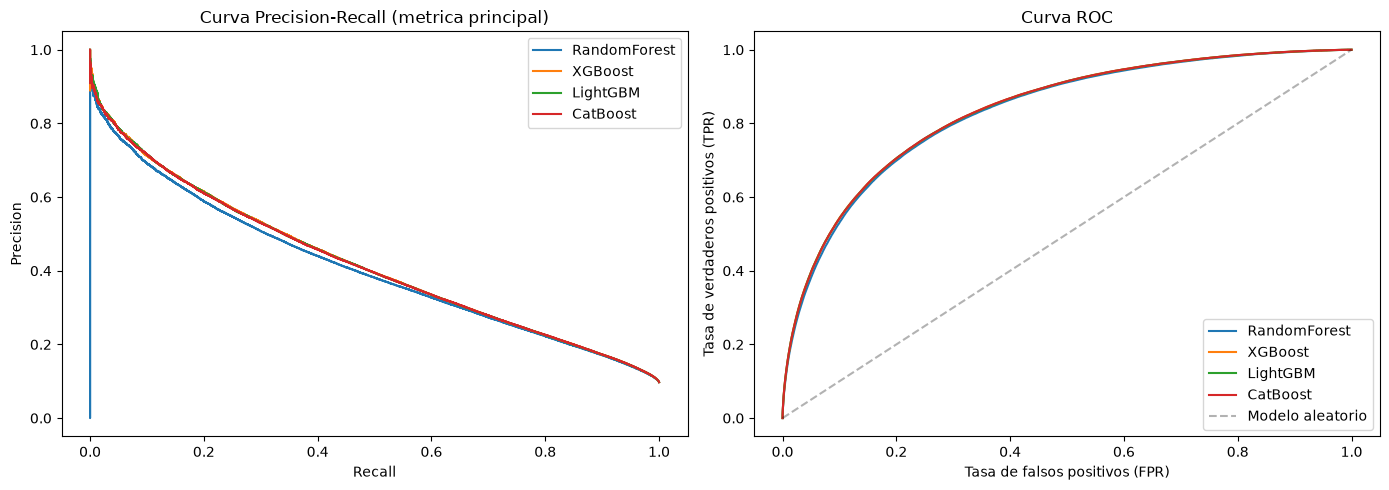

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for nombre, proba in models_proba.items():
    prec, rec, _ = precision_recall_curve(y_val, proba)
    axes[0].plot(rec, prec, label=nombre)

    fpr, tpr, _ = roc_curve(y_val, proba)
    axes[1].plot(fpr, tpr, label=nombre)

axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Curva Precision-Recall (metrica principal)')
axes[0].legend()

axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Modelo aleatorio')
axes[1].set_xlabel('Tasa de falsos positivos (FPR)')
axes[1].set_ylabel('Tasa de verdaderos positivos (TPR)')
axes[1].set_title('Curva ROC')
axes[1].legend()

plt.tight_layout()
plt.show()

### Matrices de confusión por modelo

Volvemos a la matriz de confusión que definimos en la sección de métricas, pero ahora la vemos de forma visual para los 4 modelos (con el umbral por defecto de 0.5, el mismo con el que se calcularon `precision`, `recall` y `f1` en la tabla de comparación). Cada celda es una de las 4 combinaciones posibles entre lo que predijo el modelo y lo que realmente pasó:

- **Arriba a la izquierda (verdadero negativo):** no iba a recomprar, predijimos que no → correcto.
- **Arriba a la derecha (falso positivo):** no iba a recomprar, predijimos que sí → recomendación de más.
- **Abajo a la izquierda (falso negativo):** sí iba a recomprar, predijimos que no → oportunidad perdida.
- **Abajo a la derecha (verdadero positivo):** sí iba a recomprar, predijimos que sí → correcto.

Nos sirve para comparar de un vistazo qué tan parecido es el patrón de aciertos/errores entre modelos, más allá del resumen numérico de la tabla.

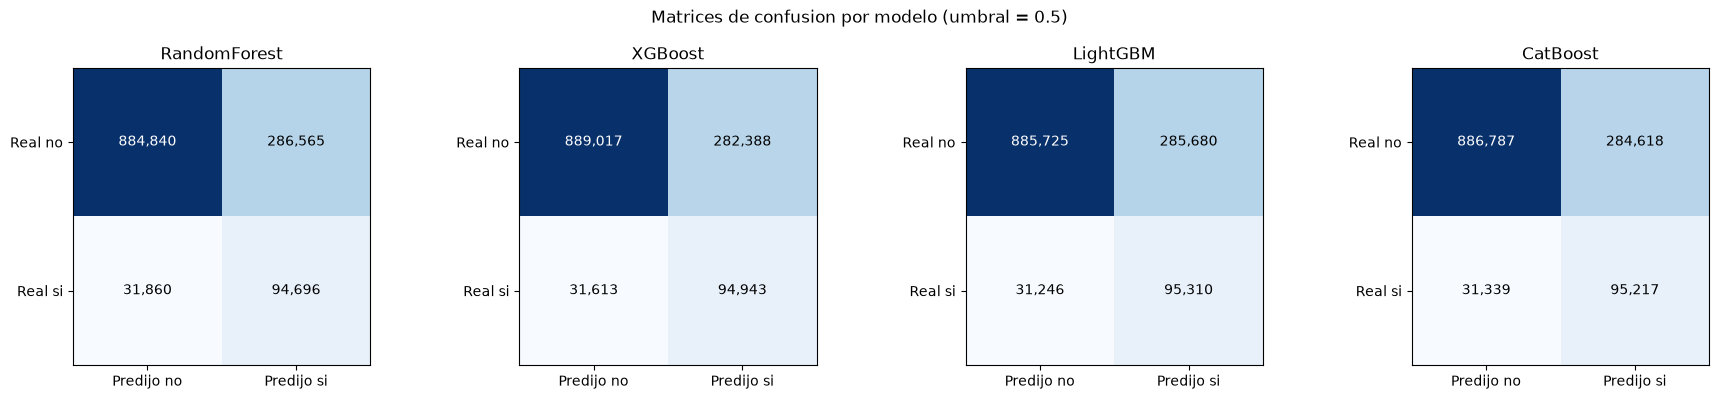

In [27]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, (nombre, m) in zip(axes, models_metrics.items()):
    matriz = np.array([[m['tn'], m['fp']], [m['fn'], m['tp']]])
    ax.imshow(matriz, cmap='Blues')
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Predijo no', 'Predijo si'])
    ax.set_yticklabels(['Real no', 'Real si'])
    ax.set_title(nombre)
    for i in range(2):
        for j in range(2):
            color = 'white' if matriz[i, j] > matriz.max() / 2 else 'black'
            ax.text(j, i, f'{matriz[i, j]:,}', ha='center', va='center', color=color)

fig.suptitle('Matrices de confusion por modelo (umbral = 0.5)')
plt.tight_layout()
plt.show()

### Importancia de features del modelo ganador

Elegimos el modelo con mejor **PR-AUC** en validación y miramos qué features tuvieron más peso en sus decisiones. Esto nos ayuda a entender *por qué* el modelo predice lo que predice, y a validar que tiene sentido de negocio (esperamos que las features de usuario×producto, como cuántas veces compró el producto y hace cuánto, sean de las más importantes).

Modelo ganador (mayor PR-AUC): XGBoost
  Precision          : 0.2516
  Recall          : 0.7502
  PR-AUC          : 0.4218
  F1 por usuario   : 0.3769
  Umbral optimo    : 0.7205


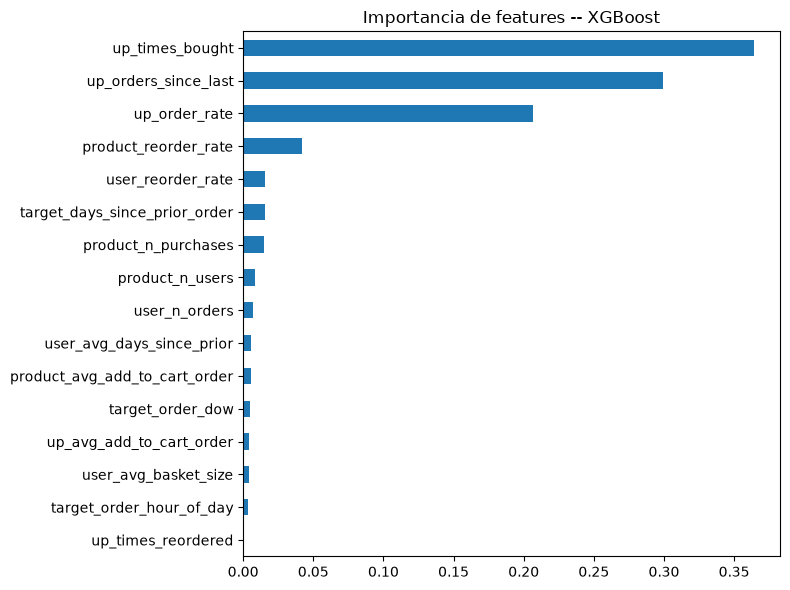

In [28]:
def obtener_importancias(modelo, feature_names):
    '''Extrae la importancia de features sea cual sea el tipo de modelo.'''
    if hasattr(modelo, 'feature_importances_'):
        imp = modelo.feature_importances_
    else:
        imp = modelo.get_feature_importance()
    return pd.Series(imp, index=feature_names).sort_values(ascending=False)


winner_name = results.iloc[0]['modelo']
winner_model = models_dict[winner_name]
winner_proba = models_proba[winner_name]
winner_metrics = models_metrics[winner_name]

print(f'Modelo ganador (mayor PR-AUC): {winner_name}')
print(f'  Precision          : {winner_metrics["precision"]:.4f}')
print(f'  Recall          : {winner_metrics["recall"]:.4f}')
print(f'  PR-AUC          : {winner_metrics["pr_auc"]:.4f}')
print(f'  F1 por usuario   : {winner_metrics["f1_por_usuario"]:.4f}')
print(f'  Umbral optimo    : {winner_metrics["best_threshold"]:.4f}')

importancias = obtener_importancias(winner_model, feature_cols)

fig, ax = plt.subplots(figsize=(8, 6))
importancias.plot(kind='barh', ax=ax)
ax.set_title(f'Importancia de features -- {winner_name}')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Fase 5 — Demo de predicción con el modelo ganador

Probamos la interfaz que buscábamos desde el inicio: dado un `user_id` y una lista de `product_id`, devolver para cada producto si el modelo predice que lo va a recomprar (`"si"`/`"no"`) junto con la probabilidad. Usamos el **umbral óptimo de F1** calculado antes, no 0.5, para decidir el corte.

In [29]:
def construir_features(user_id, product_ids):
    '''Arma la tabla de features para un usuario y una lista de productos,
    reutilizando las tablas de features ya calculadas en este notebook.
    '''
    df = pd.DataFrame({'user_id': user_id, 'product_id': product_ids})
    df = df.merge(user_features, on='user_id', how='left')
    df = df.merge(product_features, on='product_id', how='left')
    df = df.merge(up_features, on=['user_id', 'product_id'], how='left')
    df = df.merge(target_context, on='user_id', how='left')
    df[feature_cols] = df[feature_cols].fillna(0)
    return df


def predecir(user_id, product_ids, modelo, threshold):
    df = construir_features(user_id, product_ids)
    proba = modelo.predict_proba(df[feature_cols])[:, 1]
    df['proba'] = proba.round(2)
    df['reorder'] = np.where(proba >= threshold, 'si', 'no')
    df = df.merge(products[['product_id', 'product_name']], on='product_id', how='left')
    return df[['product_id', 'product_name', 'proba', 'reorder']]


products = pd.read_csv(DATA_RAW / 'products.csv', usecols=['product_id', 'product_name'])

ejemplo_user = int(sample_users[0])
ejemplo_productos = candidates.loc[candidates['user_id'] == ejemplo_user, 'product_id'].head(6).tolist()

print(f'Ejemplo para el usuario {ejemplo_user}:')
predecir(ejemplo_user, ejemplo_productos, winner_model, winner_metrics['best_threshold'])

Ejemplo para el usuario 1:


,product_id,product_name,proba,reorder
0,196,Soda,0.99,si
1,12427,Original Beef Jerky,0.98,si
2,10258,Pistachios,0.97,si
3,25133,Organic String Cheese,0.96,si
4,10326,Organic Fuji Apples,0.37,no
5,17122,Honeycrisp Apples,0.37,no


## Fase 6 — Persistencia del modelo

Guardamos un artefacto autocontenido (`.joblib`) con el modelo ganador, el umbral óptimo, la lista de features y las tablas de features precomputadas de los usuarios de la muestra — así, `src/reorder_predictor.py` puede predecir sin tener que releer ni reprocesar los CSV crudos. También exportamos las métricas de comparación a JSON, siguiendo la misma convención que los notebooks anteriores.

In [30]:
def _to_py(obj):
    '''Convierte tipos numpy a tipos nativos de Python para poder serializar a JSON.'''
    if isinstance(obj, dict):
        return {str(k): _to_py(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [_to_py(v) for v in obj]
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    return obj


MODEL_PATH   = MODELS / 'reorder_model.joblib'
METRICS_PATH = DATA_PROC / 'reorder_metrics.json'

artifact = {
    'model': winner_model,
    'model_name': winner_name,
    'feature_cols': feature_cols,
    'threshold': float(winner_metrics['best_threshold']),
    'user_features': user_features,
    'product_features': product_features,
    'up_features': up_features,
    'target_context': target_context,
    'id_to_name': dict(zip(products['product_id'], products['product_name'])),
    'metadata': {
        'generated_at': datetime.now(timezone.utc).isoformat(),
        'n_users_sample': int(len(sample_users)),
        'n_candidates': int(len(candidates)),
        'random_state': RANDOM_STATE,
        'source_notebook': '10_Reorder_Prediction.ipynb',
    },
}
joblib.dump(artifact, MODEL_PATH)
print(f'modelo exportado a {MODEL_PATH}')

metrics_export = {
    'comparacion_modelos': _to_py(results.to_dict(orient='records')),
    'modelo_ganador': winner_name,
    'threshold_optimo': float(winner_metrics['best_threshold']),
    'n_usuarios_muestra': int(len(sample_users)),
    'n_pares_candidatos': int(len(candidates)),
    'positivos_pct': float(100 * pos / (neg + pos)),
}
with open(METRICS_PATH, 'w', encoding='utf-8') as f:
    json.dump(metrics_export, f, indent=2, ensure_ascii=False)
print(f'metricas exportadas a {METRICS_PATH}')

modelo exportado a ..\models\reorder_model.joblib
metricas exportadas a ..\data\processed\reorder_metrics.json


## Validación del contrato productivo

Por último, importamos `ReorderPredictor` desde `src/` (la versión "productiva" de este modelo) y verificamos que reproduce el mismo tipo de salida que probamos en la demo, cargando el modelo ya persistido en disco.

In [31]:
import sys
sys.path.append('../src')
from reorder_predictor import ReorderPredictor

model = ReorderPredictor.load()  # sin argumentos: encuentra models/reorder_model.joblib solo

resultado = model.predict(ejemplo_user, ejemplo_productos)
print('salida final (formato exportable):')
resultado

salida final (formato exportable):


[{'product_id': 196, 'product_name': 'Soda', 'reorder': 'si', 'proba': 0.99},
 {'product_id': 12427,
  'product_name': 'Original Beef Jerky',
  'reorder': 'si',
  'proba': 0.98},
 {'product_id': 10258,
  'product_name': 'Pistachios',
  'reorder': 'si',
  'proba': 0.97},
 {'product_id': 25133,
  'product_name': 'Organic String Cheese',
  'reorder': 'si',
  'proba': 0.96},
 {'product_id': 10326,
  'product_name': 'Organic Fuji Apples',
  'reorder': 'no',
  'proba': 0.37},
 {'product_id': 17122,
  'product_name': 'Honeycrisp Apples',
  'reorder': 'no',
  'proba': 0.37}]

## Fase 7 — Dataset de prueba para testear el modelo aparte de esta notebook

Para no tener que volver a ejecutar toda esta notebook cada vez que se quiera probar `ReorderPredictor`, exportamos una muestra de pares (usuario, producto) del **set de validación** (que el modelo no vio durante el entrenamiento) junto con la **verdad conocida** (`y_true`: si ese producto realmente fue recomprado o no en el próximo pedido). Con este archivo se puede llamar a `model.predict(...)` y comparar directamente contra `y_true`, sin depender de este notebook.

Tomamos una muestra balanceada (mitad casos de recompra, mitad de no recompra) para que sea representativa de ambas clases y no quede sesgada hacia el "no", que es la clase mayoritaria.

In [32]:
N_TEST_POR_CLASE = 500

val_dataset = dataset.loc[val_mask, ['user_id', 'product_id', 'y']]

muestras_por_clase = [
    grupo.sample(n=min(N_TEST_POR_CLASE, len(grupo)), random_state=RANDOM_STATE)
    for _, grupo in val_dataset.groupby('y')
]

test_examples = (
    pd.concat(muestras_por_clase, ignore_index=True)
    .merge(products[['product_id', 'product_name']], on='product_id', how='left')
    .rename(columns={'y': 'y_true'})
    [['user_id', 'product_id', 'product_name', 'y_true']]
    .sample(frac=1, random_state=RANDOM_STATE)  # mezclamos el orden
    .reset_index(drop=True)
)

TEST_EXAMPLES_PATH = DATA_PROC / 'reorder_test_examples.csv'
test_examples.to_csv(TEST_EXAMPLES_PATH, index=False)

print(f'Dataset de prueba exportado a {TEST_EXAMPLES_PATH}')
print(f'Filas: {len(test_examples):,}  (usuarios distintos: {test_examples["user_id"].nunique():,})')
print(test_examples['y_true'].value_counts())
test_examples.head()

Dataset de prueba exportado a ..\data\processed\reorder_test_examples.csv
Filas: 1,000  (usuarios distintos: 967)
y_true
1    500
0    500
Name: count, dtype: int64


,user_id,product_id,product_name,y_true
0,88956,33156,Seitan wheat Strips,1
1,153681,13249,Skim Milk,1
2,10183,4799,Shredded Parmesan,1
3,38817,13176,Bag of Organic Bananas,1
4,181617,23985,Baby Eggplant,0
